In [27]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from scipy.stats import chi2
import uproot

from daq import sum_daq_muon, sum_daq_time
from plot_style import set_plot_style, set_plot_colorbar_style
from timestamp import TimeStamp

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times"],
    # small preamble to support \text and amsmath usage
    "text.latex.preamble": r"\usepackage{amsmath}\usepackage{siunitx}",
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.dpi": 100,
})

In [28]:
filename = "~/Documents/test/analysis_ibd_summary_test/ReProd25C/RUN.9789-9899.output.reprod25c.root"
with uproot.open(filename) as f:
    tree_wo_neu = f["FirstCrossCheckAnalysis__OMILREC_JVtx"]
    tree_w_neu = f["IBDWithNeutronVetoStudy__OMILREC_JVtx"]
    ibd_wo_neu = {
        "posx_p": tree_wo_neu["posx_p"].array(library="np"),
        "posy_p": tree_wo_neu["posy_p"].array(library="np"),
        "posz_p": tree_wo_neu["posz_p"].array(library="np"),
        "e_p": tree_wo_neu["e_p"].array(library="np"),
        "totq_p": tree_wo_neu["totq_p"].array(library="np"),
        "ts_p": np.array([TimeStamp(sec, nsec) for sec, nsec in zip(tree_wo_neu["sec_p"].array(library="np"), tree_wo_neu["nsec_p"].array(library="np"))]),
        "posx_d": tree_wo_neu["posx_d"].array(library="np"),
        "posy_d": tree_wo_neu["posy_d"].array(library="np"),
        "posz_d": tree_wo_neu["posz_d"].array(library="np"),
        "e_d": tree_wo_neu["e_d"].array(library="np"),
        "totq_d": tree_wo_neu["totq_d"].array(library="np"),
        "ts_d": np.array([TimeStamp(sec, nsec) for sec, nsec in zip(tree_wo_neu["sec_d"].array(library="np"), tree_wo_neu["nsec_d"].array(library="np"))]),
    }

    ibd_w_neu = {
        "posx_p": tree_w_neu["posx_p"].array(library="np"),
        "posy_p": tree_w_neu["posy_p"].array(library="np"),
        "posz_p": tree_w_neu["posz_p"].array(library="np"),
        "e_p": tree_w_neu["e_p"].array(library="np"),
        "totq_p": tree_w_neu["totq_p"].array(library="np"),
        "ts_p": np.array([TimeStamp(sec, nsec) for sec, nsec in zip(tree_w_neu["sec_p"].array(library="np"), tree_w_neu["nsec_p"].array(library="np"))]),
        "posx_d": tree_w_neu["posx_d"].array(library="np"),
        "posy_d": tree_w_neu["posy_d"].array(library="np"),
        "posz_d": tree_w_neu["posz_d"].array(library="np"),
        "e_d": tree_w_neu["e_d"].array(library="np"),
        "totq_d": tree_w_neu["totq_d"].array(library="np"),
        "ts_d": np.array([TimeStamp(sec, nsec) for sec, nsec in zip(tree_w_neu["sec_d"].array(library="np"), tree_w_neu["nsec_d"].array(library="np"))]),
    }

daq_days = sum_daq_time(filename)

/tmp/ipykernel_528822/450321090.py:45: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


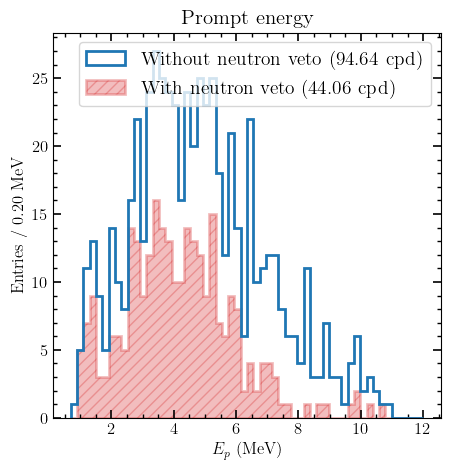

In [29]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

bin_min = 0.7
bin_max = 12.0
bin_width = 0.20
bin_num = (bin_max - bin_min) / bin_width
bins = np.linspace(bin_min, bin_max, int(bin_num) + 1)
bin_width = bins[1] - bins[0]

ibd_wo_neu_count = len(ibd_wo_neu["e_p"])
ibd_wo_neu_rate = ibd_wo_neu_count / daq_days
ibd_w_neu_count = len(ibd_w_neu["e_p"])
ibd_w_neu_rate = ibd_w_neu_count / daq_days

ax.hist(
    ibd_wo_neu["e_p"], 
    bins=bins,
    color="tab:blue",
    histtype="step",
    linewidth=2.0,
    label=f"Without neutron veto ({ibd_wo_neu_rate:.2f} cpd)"
)

ax.hist(
    ibd_w_neu["e_p"],
    bins=bins,
    histtype="stepfilled",
    facecolor="tab:red",
    edgecolor="tab:red",
    alpha=0.3,
    hatch="///",
    linewidth=2.0,
    label=f"With neutron veto ({ibd_w_neu_rate:.2f} cpd)"
)

ax.set_xlabel(r"$E_p$ (MeV)", fontsize=12)
ax.set_ylabel(fr"Entries / {bin_width:.2f} MeV", fontsize=12)
ax.set_title(r"Prompt energy", fontsize=15)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontsize(20)

ax.legend(fontsize=14)

set_plot_style(ax)
fig.show()

/tmp/ipykernel_528822/4243830979.py:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


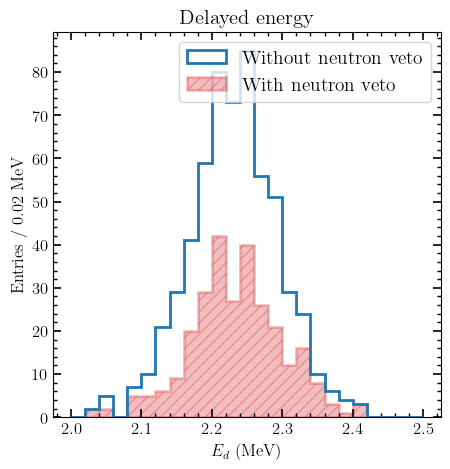

In [30]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

bin_min = 2.0
bin_max = 2.5
bin_width = 0.02
bin_num = (bin_max - bin_min) / bin_width
bins = np.linspace(bin_min, bin_max, int(bin_num) + 1)
bin_width = bins[1] - bins[0]

ax.hist(
    ibd_wo_neu["e_d"], 
    bins=bins,
    color="tab:blue",
    histtype="step",
    linewidth=2.0,
    label="Without neutron veto"
)

ax.hist(
    ibd_w_neu["e_d"],
    bins=bins,
    histtype="stepfilled",
    facecolor="tab:red",
    edgecolor="tab:red",
    alpha=0.3,
    hatch="///",
    linewidth=2.0,
    label="With neutron veto"
)

ax.set_xlabel(r"$E_d$ (MeV)", fontsize=12)
ax.set_ylabel(fr"Entries / {bin_width:.2f} MeV", fontsize=12)
ax.set_title(r"Delayed energy", fontsize=15)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontsize(20)

ax.legend(fontsize=14)

set_plot_style(ax)
fig.show()

/tmp/ipykernel_528822/6063250.py:54: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


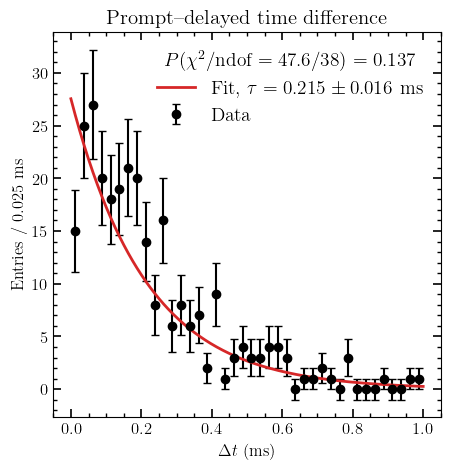

In [31]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

dt_ms = np.array([(ibd_w_neu["ts_d"][k] - ibd_w_neu["ts_p"][k]).to_sec() * 1000.0 for k in range(len(ibd_w_neu["ts_d"]))])

bin_min = 0.0
bin_max = 1.0
bin_width = 0.025
bin_num = (bin_max - bin_min) / bin_width
bins = np.linspace(bin_min, bin_max, int(bin_num) + 1)
bin_width = bins[1] - bins[0]

counts, edges = np.histogram(dt_ms, bins=bins)
centers = 0.5 * (edges[:-1] + edges[1:])

errors = np.sqrt(counts)
errors[errors == 0] = 1.0

def expo(t, A, tau):
    return A * np.exp(-t / tau)

popt, pcov = curve_fit(expo, centers, counts, sigma=errors, absolute_sigma=True)
A_fit, tau_fit = popt
A_err, tau_err = np.sqrt(np.diag(pcov))

model = expo(centers, *popt)
chi2_val = np.sum(((counts - model) / errors) ** 2)
ndof = len(counts) - len(popt)
p_value = chi2.sf(chi2_val, ndof)

ax.errorbar(
    centers, counts, yerr=errors,
    fmt='o', color="black", markersize=6, capsize=3, label='Data'
)

t_fit = np.linspace(bin_min, bin_max, 400)
ax.plot(t_fit, expo(t_fit, *popt), color="tab:red", linewidth=2,
        label=fr"Fit, $\tau = {tau_fit:.3f} \pm {tau_err:.3f}$ ms"
)

ax.set_xlabel(r"$\Delta t$ (ms)", fontsize=12)
ax.set_ylabel(fr"Entries / {bin_width:.3f} ms", fontsize=12)
ax.set_title(r"Prompt–delayed time difference", fontsize=15)

ax.tick_params(axis='both', which='major', labelsize=16)

ax.legend(
    title=fr"$P(\chi^2 / \mathrm{{ndof}} = {chi2_val:.1f} / {ndof}) = {p_value:.3f}$",
    fontsize=14,
    title_fontsize=14,
    frameon=False
)

set_plot_style(ax)
fig.show()

/tmp/ipykernel_528822/1642226824.py:30: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


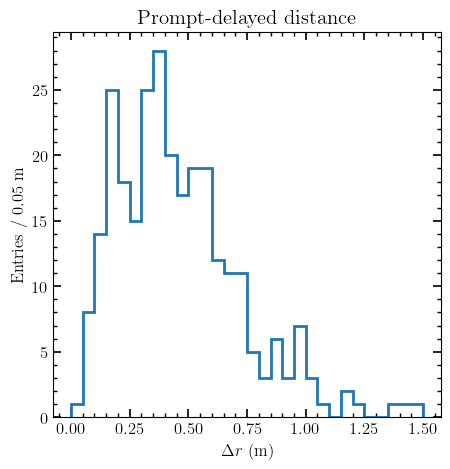

In [32]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

dr = np.linalg.norm(
    np.stack([ibd_w_neu["posx_d"] - ibd_w_neu["posx_p"], ibd_w_neu["posy_d"] - ibd_w_neu["posy_p"], ibd_w_neu["posz_d"] - ibd_w_neu["posz_p"]]),
    axis=0
) / 1000.0 # m to mm

bin_min = 0.0
bin_max = 1.5
bin_width = 0.05
bin_num = (bin_max - bin_min) / bin_width
bins = np.linspace(bin_min, bin_max, int(bin_num) + 1)
bin_width = bins[1] - bins[0]

ax.hist(
    dr, 
    bins=bins,
    color="tab:blue",
    histtype="step",
    linewidth=2.0
)

ax.set_xlabel(r"$\Delta r$ (m)", fontsize=12)
ax.set_ylabel(fr"Entries / {bin_width:.2f} m", fontsize=12)
ax.set_title(r"Prompt-delayed distance", fontsize=15)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontsize(20)

set_plot_style(ax)
fig.show()

/tmp/ipykernel_528822/3971465034.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


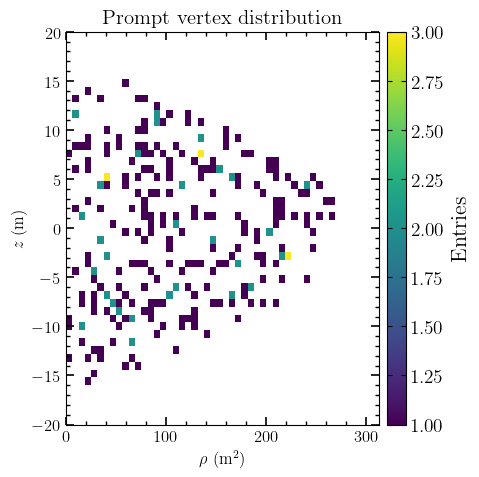

In [33]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

rho2_p = (ibd_w_neu["posx_p"]**2 + ibd_w_neu["posy_p"]**2) / 1e6 # mm^2 to m^2
z_p   = ibd_w_neu["posz_p"] / 1000.0  # mm to m

h, xedges, yedges, img = ax.hist2d(
    rho2_p, z_p,
    bins=(np.linspace(0.0, 17.7 * 17.7, 51), np.linspace(-20.0, 20.0, 51)),
    cmap="viridis",
    cmin=1.0,
    norm=None # LogNorm()
)

ax.set_xlabel(r"$\rho$ (m$^2$)", fontsize=12)
ax.set_ylabel(r"$z$ (m)", fontsize=12)
ax.set_title(r"Prompt vertex distribution", fontsize=15)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontsize(14)

set_plot_style(ax)

cbar = fig.colorbar(img, ax=ax, pad=0.02)
cbar.set_label("Entries", fontsize=16)
cbar.ax.tick_params(labelsize=14)
set_plot_colorbar_style(cbar.ax)

fig.tight_layout()
fig.show()

/tmp/ipykernel_528822/1936782978.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


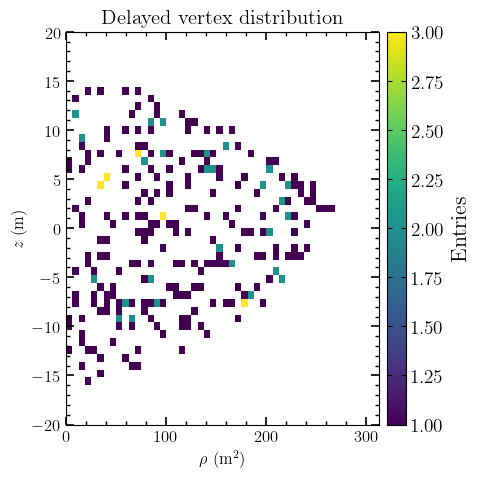

In [34]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

rho2_d = (ibd_w_neu["posx_d"]**2 + ibd_w_neu["posy_d"]**2) / 1e6 # mm^2 to m^2
z_d   = ibd_w_neu["posz_d"] / 1000.0  # mm to m

h, xedges, yedges, img = ax.hist2d(
    rho2_d, z_d,
    bins=(np.linspace(0.0, 17.7 * 17.7, 51), np.linspace(-20.0, 20.0, 51)),
    cmap="viridis",
    cmin=1.0,
    norm=None # LogNorm()
)

ax.set_xlabel(r"$\rho$ (m$^2$)", fontsize=12)
ax.set_ylabel(r"$z$ (m)", fontsize=12)
ax.set_title(r"Delayed vertex distribution", fontsize=15)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontsize(14)

set_plot_style(ax)

cbar = fig.colorbar(img, ax=ax, pad=0.02)
cbar.set_label("Entries", fontsize=16)
cbar.ax.tick_params(labelsize=14)
set_plot_colorbar_style(cbar.ax)

fig.tight_layout()
fig.show()